# Task 1

*Скачайте датасет Fashion MNIST, посмотрите на картинки, отделите валидационную выборку и обучите одну полносвязную архитектуру. Выведите summary модели, посмотрите на графики обучения, сделайте выводы*.

---



In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # использую gpu если есть
print(device)

cuda


In [ ]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
# откалибруем данные через ToTensor, чтобы значения были в диапазоне от 0.0 до 1.0 для каждого канала
train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
) # для обучения

test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
) # для тестинга

train_data.data.shape, test_data.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

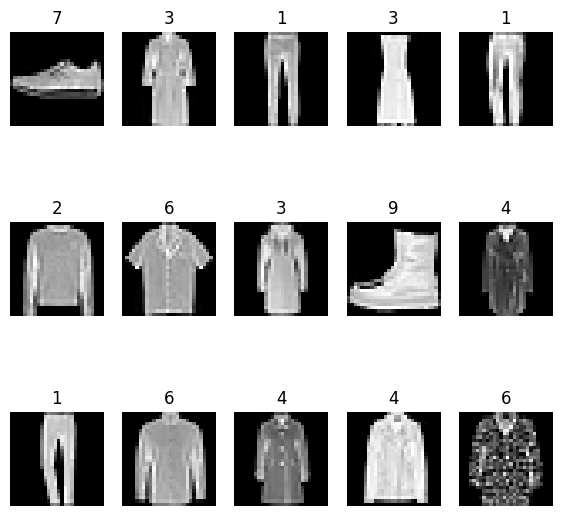

In [ ]:
import matplotlib.pyplot as plt

def visualize(data): # визуализируем датасет
  fig = plt.figure(figsize=(7, 7))

  cols, rows = 5, 3

  for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,), device=device).item() # рандомная картинка, используем сразу GPU для рандома
    img, label = data[sample_idx]

    fig.add_subplot(rows, cols, i)

    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

visualize(train_data) # визуализация

In [ ]:
!pip install torchinfo

In [ ]:
from torch import nn

class DenseNeuralNetwork(nn.Module):
  def __init__(self, layers, dropout_rate):
    super().__init__()
    self.flatten = nn.Flatten() # (n, 1, 28, 28) -> (n, 1, 784)
    in_features = 784 # 28x28 фото
    self.model = nn.Sequential()

    for out_features in layers:
      self.model.append(nn.Linear(in_features, out_features))
      self.model.append(nn.BatchNorm1d(out_features)) # для масштабирования данных
      self.model.append(nn.ReLU()) # функция активации
      self.model.append(nn.Dropout(dropout_rate)) # борьба с overfitting'ом
      in_features = out_features

    self.model.append(nn.Linear(in_features, 10)) # финальное преобразование к 10 классам

  def forward(self, x):
    x = self.flatten(x)
    logits = self.model(x)
    return logits


# Выведем summary модели

from torchinfo import summary

fashion_classifier = DenseNeuralNetwork(layers=[256, 128, 64, 10], dropout_rate=0.1).to(device)
print(summary(fashion_classifier, input_size=(1, 1, 28, 28)))


Layer (type:depth-idx)                   Output Shape              Param #
DenseNeuralNetwork                       [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 256]                  200,960
│    └─BatchNorm1d: 2-2                  [1, 256]                  512
│    └─ReLU: 2-3                         [1, 256]                  --
│    └─Dropout: 2-4                      [1, 256]                  --
│    └─Linear: 2-5                       [1, 128]                  32,896
│    └─BatchNorm1d: 2-6                  [1, 128]                  256
│    └─ReLU: 2-7                         [1, 128]                  --
│    └─Dropout: 2-8                      [1, 128]                  --
│    └─Linear: 2-9                       [1, 64]                   8,256
│    └─BatchNorm1d: 2-10                 [1, 64]                   128


In [ ]:
from torch import optim
from torch.utils.data import DataLoader

optimizer = torch.optim.SGD(fashion_classifier.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

import os
# разделим данные на батчи
batch_size = 256
num_of_epochs = 100

num_workers = min(8, os.cpu_count()) # для многопоточности

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # обучающая выборка
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True) # тестовая выборка

# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в диск

In [ ]:
!pip install pytorch-ignite

In [ ]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall, Fbeta

trainer = create_supervised_trainer(fashion_classifier, optimizer, criterion, device)

metrics = {
    "accuracy": Accuracy(),
    "precision": Precision(average=True),
    "recall": Recall(average=True),
    "f1_score": Fbeta(average=True, beta=1.0),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на обучающей выборке
test_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на тестовой выборке

In [ ]:
from IPython.display import clear_output

def show_loss(train_losses, test_losses, train_accuracies, test_accuracies):
  clear_output()

  plt.figure(figsize=(15,15))

  plt.subplot(2, 2, 1)
  plt.title('Train Loss')
  plt.plot(np.arange(len(train_losses)), train_losses)  # лосс обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 2)
  plt.title('Test Loss')
  plt.plot(np.arange(len(test_losses)), test_losses) # лосс тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 3)
  plt.title('Train Accuracy')
  plt.plot(np.arange(len(train_accuracies)), train_accuracies) # accuracy обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 4)
  plt.title('Test Accuracy')
  plt.plot(np.arange(len(test_accuracies)), test_accuracies) # accuracy тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.show()


In [ ]:
from ignite.engine import Events


train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

test_y_true = []
test_y_pred = []

experiment = []

best_avg_error, best_epoch = float("inf"), 0

def compute_epoch_results(engine):
    global best_avg_error, best_epoch, experiment
    train_evaluator.run(train_loader)
    test_evaluator.run(test_loader)
    # Сохраняем метрики
    train_losses.append(train_evaluator.state.metrics["loss"])
    test_losses.append(test_evaluator.state.metrics["loss"])
    train_accuracies.append(train_evaluator.state.metrics["accuracy"])
    test_accuracies.append(test_evaluator.state.metrics["accuracy"])

    if test_losses[-1] < best_avg_error: # проверяем есть ли какие-либо улучшения
        best_avg_error = test_losses[-1]
        experiment = [{
            "Min Validation Loss": best_avg_error,
            "Accuracy": test_evaluator.state.metrics["accuracy"],
            "Precision": test_evaluator.state.metrics["precision"],
            "Recall": test_evaluator.state.metrics["recall"],
            "F1-score": test_evaluator.state.metrics["f1_score"]
        }]

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)


trainer.add_event_handler(
    Events.EPOCH_COMPLETED(every=10),
    lambda engine: show_loss(train_losses, test_losses, train_accuracies, test_accuracies)
)

def log_epoch_results(engine, label=""):
    result = ', '.join([f"{m} = {v}" for m, v in engine.state.metrics.items()])
    print(f"{label} Res:", result)

train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
test_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler
from ignite.handlers import EarlyStopping

scheduler = ReduceLROnPlateauScheduler(
    optimizer,
    mode='min',
    metric_name="loss",
    factor=0.1,
    patience=5,
    threshold=0.05
)

test_evaluator.add_event_handler(Events.COMPLETED, scheduler) # снижает lr у оптимайзера, если не было улучшений

early_stopping = EarlyStopping(patience=10, score_function=lambda x: -test_evaluator.state.metrics["loss"] , trainer=trainer) # для своевременной остановки если не было улучшений

test_evaluator.add_event_handler(Events.COMPLETED, early_stopping) # если при запуске валидации не было улучшений останавливаем

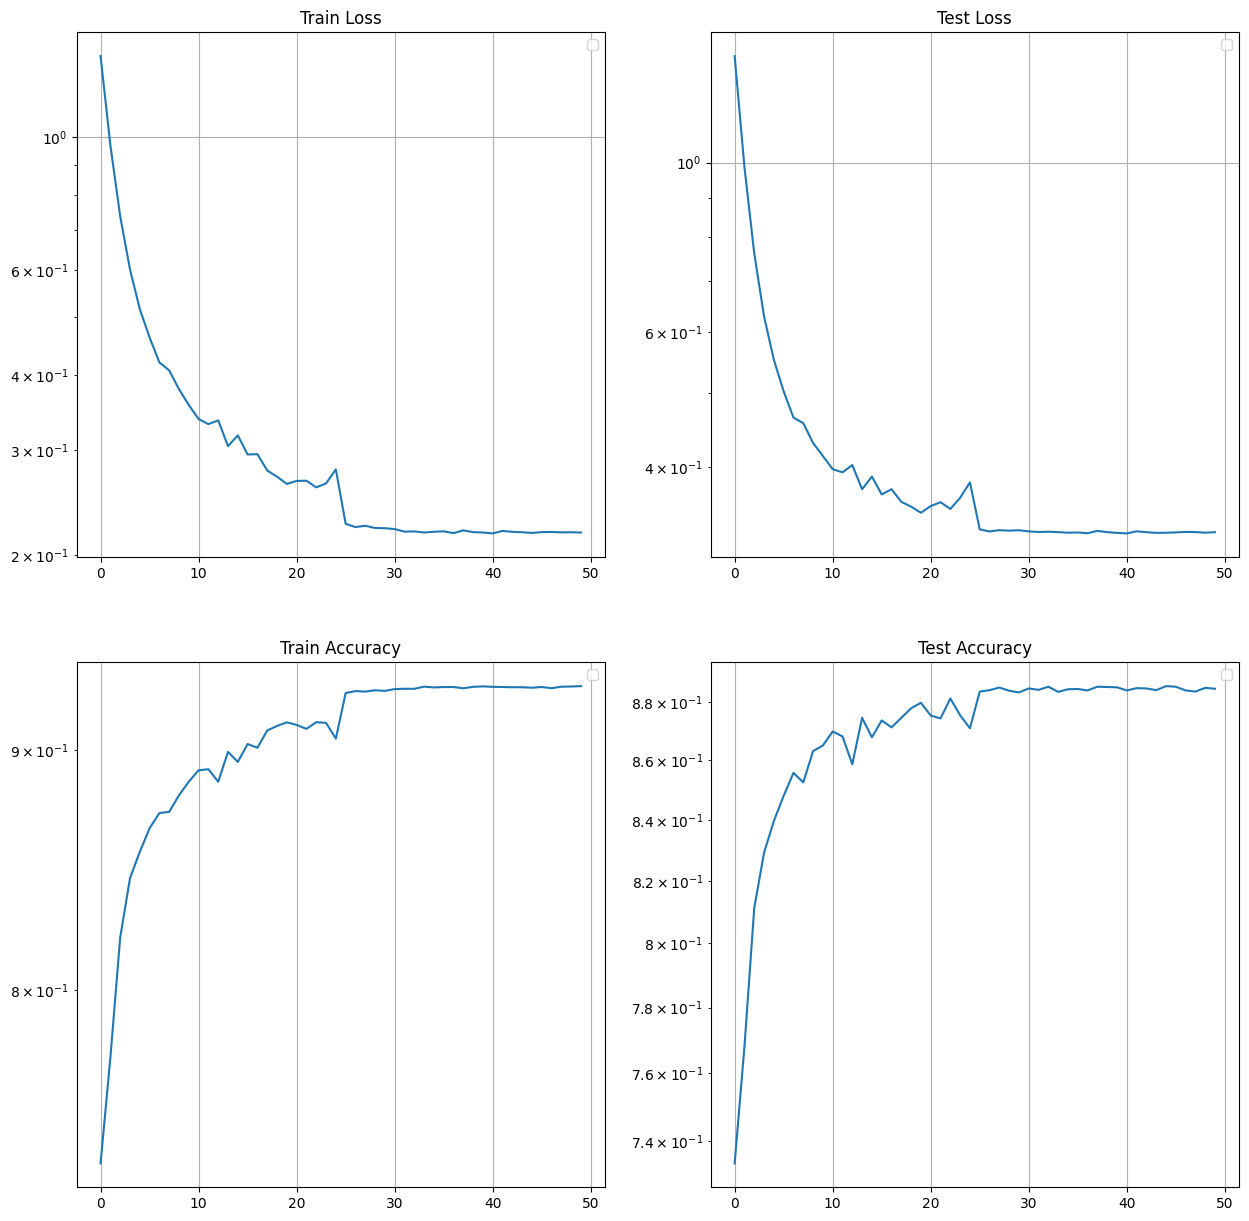

Train Res: accuracy = 0.9282, precision = 0.9278528223706924, recall = 0.9282, f1_score = 0.9278664425355683, loss = 0.21737698567708333


2025-03-24 19:23:25,994 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Valid Res: accuracy = 0.8846, precision = 0.8838814571266035, recall = 0.8846, f1_score = 0.8840485100866304, loss = 0.327750390625


State:
	iteration: 11985
	epoch: 51
	epoch_length: 235
	max_epochs: 100
	output: 0.346609503030777
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

In [ ]:
trainer.run(train_loader, max_epochs=num_of_epochs)

# Test Loss:

На первых 10 эпохах наблюдается резкий спад функции потерь, что говорит о быстром обучении модели и быстрой адаптации к тестовой выборке. После 10-й эпохи снижение продолжается, но уже менее стремительно. Между 10-й и 25-й эпохами видны колебания, с резкими подъемами, однако в целом тренд сохраняется убывающим. Начиная примерно с 25-й эпохи, функция потерь стабилизируется на довольно низком уровне и остается практически неизменной до конца обучения, с минимальными колебаниями. Скорее всего, модель достигла области минимума и сохраняет устойчивое поведение на тестовой выборке.

# Test Accuracy:

Точность на тестовой выборке демонстрирует активный рост с 1-й по 10-ю эпоху, что свидетельствует о том, что модель быстро адаптируется. После 10-й эпохи рост продолжается, но довольно много колебаний. Примерно с 27-й эпохи точность стабилизируется на уровне около 0.88, показывая устойчивость модели к переобучению. Начиная с 30-й эпохи, улучшения становятся минимальными, однако точность остаётся высокой и стабильной вплоть до 50-й эпохи, что говорит о хорошем обобщающем свойстве модели.

In [ ]:
import pandas as pd

report = pd.DataFrame(experiment)

print(report)

   Min Validation Loss  Accuracy  Precision  Recall  F1-score
0             0.327724     0.884   0.883139   0.884   0.88333


# Вывод:

Модель показывает неплохие результаты, однако она всё ещё далека от эталона. Насколько я понимаю, это связано с тем, что полносвязные нейросети не учитывают пространственные признаки. Например, если поменять местами два пикселя, модель может выдать полностью другой результат.

Отчет:


 |Min Validation Loss | Accuracy | Precision | Recall |  F1-score |
 |--------------------|----------|-----------|--------|-----------|
 |          0.327724  |   0.884  | 0.883139  | 0.884  | 0.88333   |

